# 53 — Blowing up small objects in segmentation masks

**Problem.** Experiment-24 smasks are almost entirely background: the object covers ~0.7% of the
full-res mask (309x679) and only ~5 px of the 20x40 downsampled training target that
`src/data/post_process.py` produces. The model is being asked to hit a tiny target.

**Idea.** Keep the total image resolution the same, but *enlarge the object region* by a
controllable linear factor `scale` (2x linear = 4x area) before downsampling. The background
stays put, the mask just claims more area around the object.

**Strategies tested** (all take a binary mask + `scale`, return a binary mask of the same shape):

| | strategy | how it grows | area control |
|---|---|---|---|
| A | `scale_objects` | geometric zoom of each object about its own center of mass | exact-ish `scale**2` by construction |
| B | `dilate_to_iters` | iterative binary dilation (cross kernel) until area >= `scale**2 * area0` | first iteration that overshoots |
| C | `edt_grow` | claim all background within Euclidean distance `r` of the object, `r` bisected to hit the target area | bisected to ~exact `scale**2` |
| D | `lowres_dilate` | downsample **first**, then dilate the 20x40 target directly | per low-res-pixel steps (coarse) |

After picking a winner, this becomes a method in `src/data/post_process.py`
(`post_process_sample` applies it to `02_smask.png` right before `downsample`), with the new
scale param entering the dataset hash key.

In [1]:
from pathlib import Path
import json

import numpy as np
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt

SAMPLE_DIR = Path(r"D:/eturok/experiment-24/samples/000005")
OUT_H, OUT_W = 20, 40          # post_process.py defaults
BLUE, ORANGE = "#3b82f6", "#f97316"   # original object / added area

mask = np.load(SAMPLE_DIR / "image/02_smask.npy") > 0.5     # (309, 679) bool
cropped = np.asarray(Image.open(SAMPLE_DIR / "image/01_cropped.png"))
meta = {k: v for d in (json.loads(l) for l in (SAMPLE_DIR / "metadata.jsonl").read_text().splitlines()) for k, v in d.items()}

H, W = mask.shape
print(f"sample {meta['sample_id']}: {meta['description']!r}")
print(f"mask {mask.shape}, object px = {mask.sum()} ({100*mask.mean():.2f}% of image)")

sample 000005: "A metal cylinder sitting on the floor of an open metal box from a bird's eye view."
mask (309, 679), object px = 1427 (0.68% of image)


## 0 — Baseline: what the model currently sees

Full-res mask, its overlay on the overhead crop, and the current 20x40 BOX-downsampled target
(exactly what `post_process.downsample` produces).

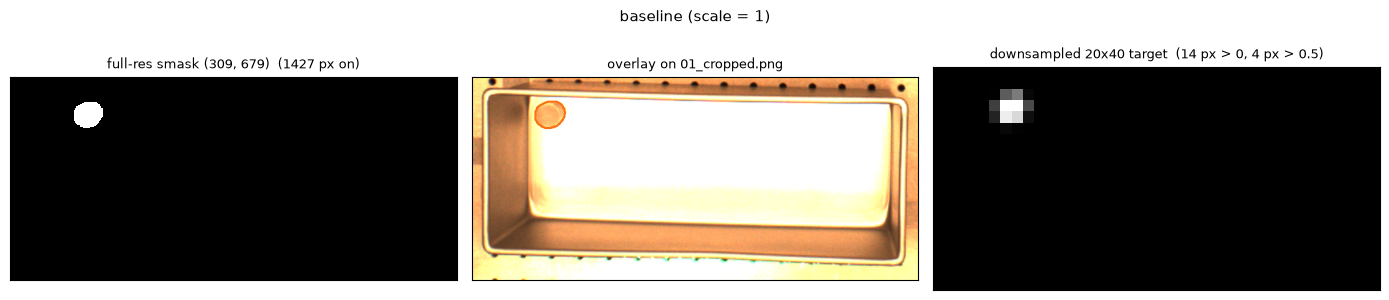

In [2]:
def downsample(m, out_h=OUT_H, out_w=OUT_W):
    # identical to src/data/post_process.py: PIL BOX resampling = area average over the full mask
    img = Image.fromarray((np.asarray(m, dtype=np.float32) * 255).astype(np.uint8))
    return np.asarray(img.resize((out_w, out_h), resample=Image.BOX), dtype=np.float32) / 255.0

def show_mask(ax, m, title, soft=False):
    ax.imshow(m, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

base_ds = downsample(mask)
fig, axs = plt.subplots(1, 3, figsize=(14, 3.2))
show_mask(axs[0], mask, f"full-res smask {mask.shape}  ({mask.sum()} px on)")
axs[1].imshow(cropped); axs[1].contour(mask, levels=[0.5], colors=[ORANGE], linewidths=1.5)
axs[1].set_title("overlay on 01_cropped.png", fontsize=9); axs[1].set_xticks([]); axs[1].set_yticks([])
show_mask(axs[2], base_ds, f"downsampled {OUT_H}x{OUT_W} target  ({int((base_ds>0).sum())} px > 0, {(base_ds>0.5).sum()} px > 0.5)")
fig.suptitle("baseline (scale = 1)", fontsize=11)
plt.tight_layout(); plt.show()

## 1 — The four blow-up strategies

Each returns a same-shape binary mask whose object area is ~`scale**2` times the original
(so `scale` reads as a *linear* magnification, "the object is 2x bigger").

In [3]:
def scale_objects(m, scale):
    """A: zoom each connected object about its own center of mass (nearest-neighbor inverse map).
    Shape and aspect are preserved exactly; area scales by scale**2 up to pixel rounding."""
    lbl, n = ndimage.label(m)
    out = np.zeros_like(m)
    rr, cc = np.mgrid[0:m.shape[0], 0:m.shape[1]]
    for i in range(1, n + 1):
        obj = lbl == i
        cr, cw = ndimage.center_of_mass(obj)
        sr = np.round((rr - cr) / scale + cr).astype(int)
        sc = np.round((cc - cw) / scale + cw).astype(int)
        ok = (sr >= 0) & (sr < m.shape[0]) & (sc >= 0) & (sc < m.shape[1])
        hit = np.zeros_like(m)
        hit[ok] = obj[sr[ok], sc[ok]]
        out |= hit
    return out

def dilate_to_iters(m, scale):
    """B: repeatedly binary-dilate (default cross kernel) until area >= scale**2 * area0."""
    target = scale**2 * m.sum()
    out = m.copy()
    while out.sum() < target:
        out = ndimage.binary_dilation(out)
    return out

def edt_grow(m, scale):
    """C: object := object + all background within Euclidean distance r; bisect r to hit
    area = scale**2 * area0. Growth is isotropic and follows the object's outline."""
    target = scale**2 * m.sum()
    if scale <= 1: return m.copy()
    dist = ndimage.distance_transform_edt(~m)
    lo, hi = 0.0, 1.0
    while (dist <= hi).sum() < target: hi *= 2
    for _ in range(40):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if (dist <= mid).sum() < target else (lo, mid)
    return dist <= hi

def lowres_dilate(m, scale, out_h=OUT_H, out_w=OUT_W):
    """D: downsample first (binarize at 0.5), then dilate the low-res target itself.
    Returns the LOW-RES mask -- growth happens after resolution is already 20x40."""
    lo = downsample(m, out_h, out_w) > 0.5
    target = scale**2 * lo.sum()
    out = lo.copy()
    while out.sum() < target:
        out = ndimage.binary_dilation(out)
    return out

STRATEGIES = {"A scale_objects": scale_objects, "B dilate_to_iters": dilate_to_iters, "C edt_grow": edt_grow}
SCALES = [1.5, 2.0, 3.0]

## 2 — Full-res comparison

Blue = original object, orange = area added by the blow-up. Titles report the achieved area
ratio (want ~`scale**2`: 2.25x, 4x, 9x). Cropped to a window around the object.

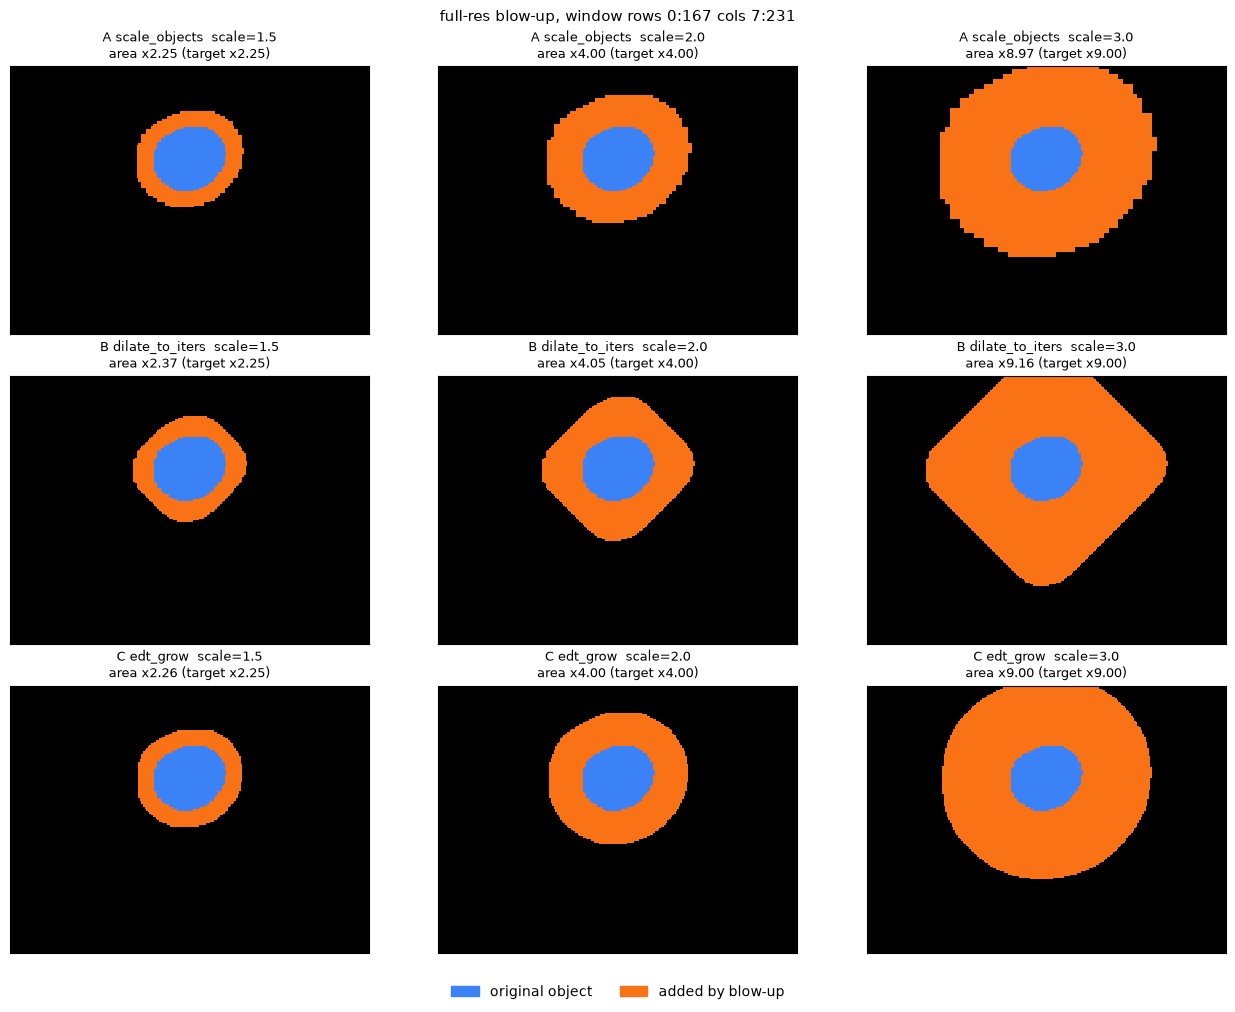

In [4]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# window around the object for readable close-ups
ys, xs = np.where(mask)
pad = 90
r0, r1 = max(ys.min()-pad, 0), min(ys.max()+pad, H)
c0, c1 = max(xs.min()-pad, 0), min(xs.max()+pad, W)

def overlay_panel(ax, orig, grown, title):
    canvas = np.zeros(orig.shape, dtype=int)          # 0 bg, 1 added, 2 original
    canvas[grown & ~orig] = 1
    canvas[orig] = 2
    cmap = ListedColormap(["#000000", ORANGE, BLUE])
    ax.imshow(canvas[r0:r1, c0:c1], cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

fig, axs = plt.subplots(len(STRATEGIES), len(SCALES), figsize=(13, 3.4*len(STRATEGIES)))
results = {}
for i, (name, fn) in enumerate(STRATEGIES.items()):
    for j, s in enumerate(SCALES):
        grown = fn(mask, s)
        results[(name, s)] = grown
        ratio = grown.sum() / mask.sum()
        overlay_panel(axs[i, j], mask, grown, f"{name}  scale={s}\narea x{ratio:.2f} (target x{s**2:.2f})")
fig.legend(handles=[Patch(color=BLUE, label="original object"), Patch(color=ORANGE, label="added by blow-up")],
           loc="lower center", ncol=2, frameon=False)
fig.suptitle(f"full-res blow-up, window rows {r0}:{r1} cols {c0}:{c1}", fontsize=11)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 3 — What actually matters: the downsampled 20x40 training target

Each blown-up full-res mask through the exact `post_process.downsample` (BOX). Values are soft
(area-averaged); the annotation counts pixels > 0.5, i.e. majority-object cells. Strategy D acts
directly on the low-res grid so it appears only here.

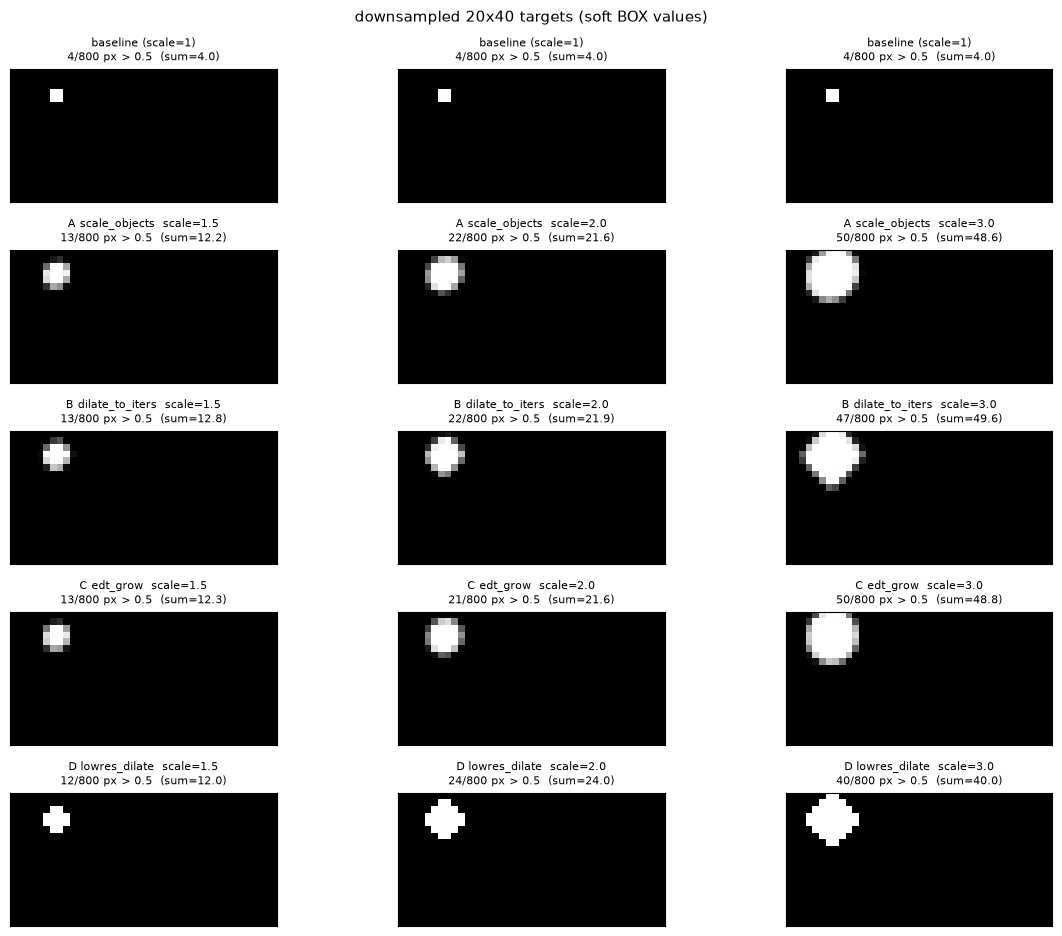

In [5]:
rows = [("baseline (scale=1)", {1.0: base_ds > 0.5})]
for name, fn in STRATEGIES.items():
    rows.append((name, {s: downsample(results[(name, s)]) for s in SCALES}))
rows.append(("D lowres_dilate", {s: lowres_dilate(mask, s).astype(float) for s in SCALES}))

ncols = len(SCALES)
fig, axs = plt.subplots(len(rows), ncols, figsize=(12, 1.9*len(rows)))
for i, (name, per_scale) in enumerate(rows):
    for j, s in enumerate(SCALES):
        ax = axs[i, j]
        if s in per_scale: ds = np.asarray(per_scale[s], dtype=float)
        elif len(per_scale) == 1: ds = np.asarray(next(iter(per_scale.values())), dtype=float)  # baseline row repeated
        ax.imshow(ds, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        n_on = int((ds > 0.5).sum())
        title = f"{name}  scale={s}" if len(per_scale) > 1 else name
        ax.set_title(f"{title}\n{n_on}/{OUT_H*OUT_W} px > 0.5  (sum={ds.sum():.1f})", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"downsampled {OUT_H}x{OUT_W} targets (soft BOX values)", fontsize=11)
plt.tight_layout(); plt.show()

## 4 — Position sanity check

The blown-up object must stay centered where the physical object is. Contours of scale 1 / 2 / 3
(strategy C) on the overhead crop; the dot marks the recorded center of mass.

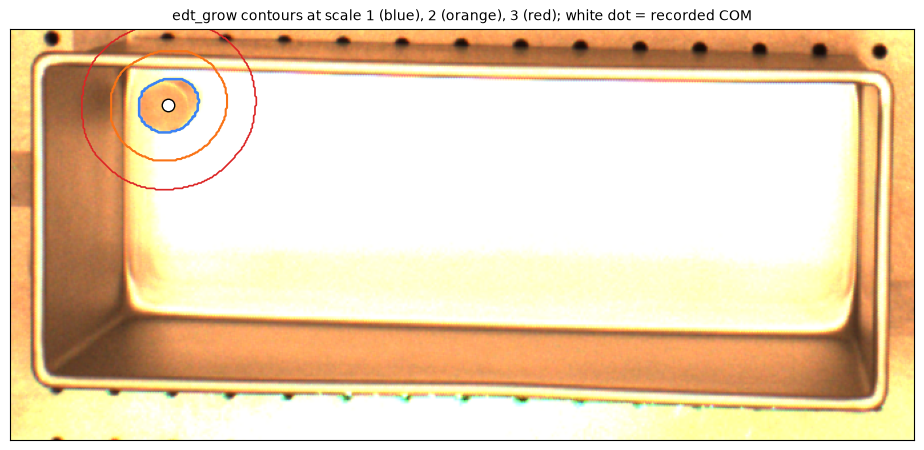

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.imshow(cropped)
for s, color, lw in [(1.0, BLUE, 1.8), (2.0, ORANGE, 1.5), (3.0, "#dc2626", 1.2)]:
    m = mask if s == 1.0 else results[("C edt_grow", s)]
    ax.contour(m, levels=[0.5], colors=[color], linewidths=lw)
com_r, com_c = meta["avg_com"]
ax.plot(com_c, com_r, "o", color="white", markersize=9, markeredgecolor="black")
ax.set_title("edt_grow contours at scale 1 (blue), 2 (orange), 3 (red); white dot = recorded COM", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5 — Multi-object behavior

Experiment-24 has multi-object layouts too. A synthetic two-blob mask checks that (A) scales each
object about its *own* COM (objects don't drift toward or away from each other) and shows where
B/C start to merge blobs at large scales.

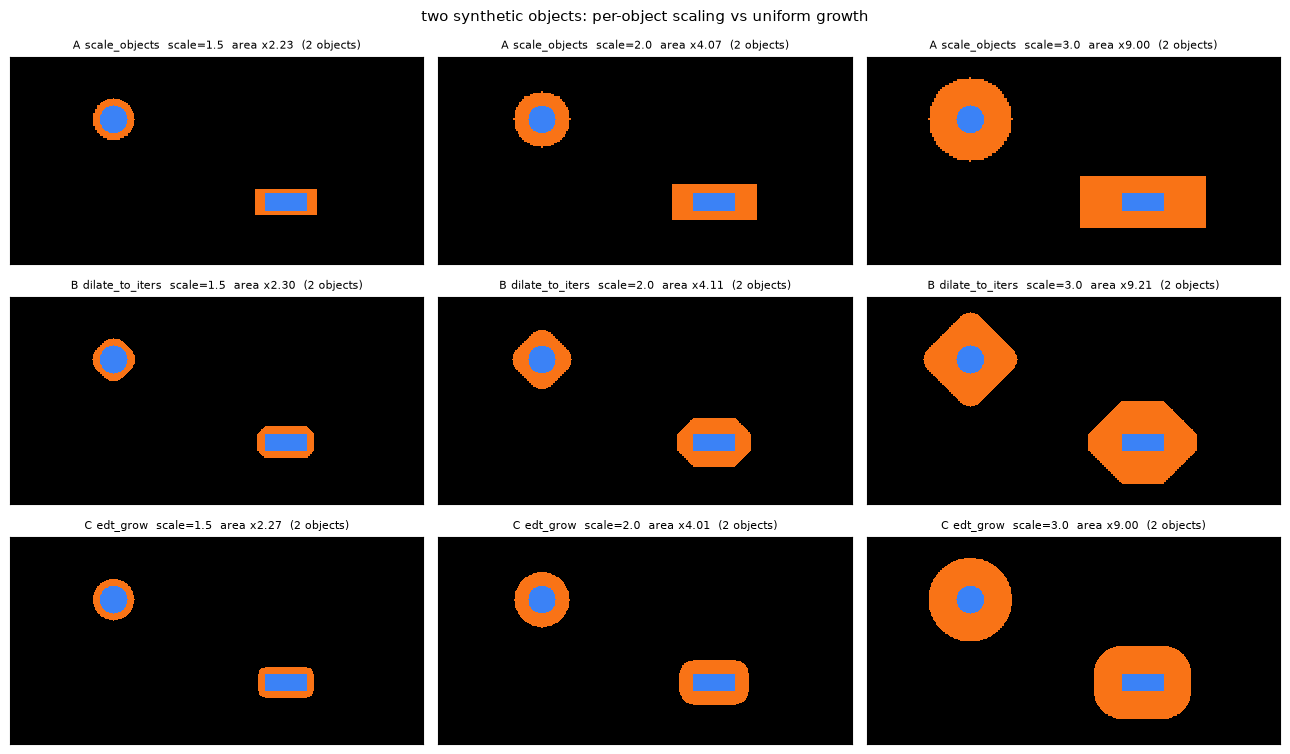

In [7]:
synth = np.zeros((300, 600), dtype=bool)
yy, xx = np.mgrid[0:300, 0:600]
synth |= (yy - 90)**2 + (xx - 150)**2 <= 20**2                  # round blob
synth |= (np.abs(yy - 210) <= 12) & (np.abs(xx - 400) <= 30)    # bar blob

fig, axs = plt.subplots(len(STRATEGIES), len(SCALES), figsize=(13, 2.6*len(STRATEGIES)))
sr0, sr1, sc0, sc1 = 0, 300, 0, 600
for i, (name, fn) in enumerate(STRATEGIES.items()):
    for j, s in enumerate(SCALES):
        grown = fn(synth, s)
        canvas = np.zeros(synth.shape, dtype=int)
        canvas[grown & ~synth] = 1
        canvas[synth] = 2
        cmap = ListedColormap(["#000000", ORANGE, BLUE])
        axs[i, j].imshow(canvas, cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
        n_obj = ndimage.label(grown)[1]
        axs[i, j].set_title(f"{name}  scale={s}  area x{grown.sum()/synth.sum():.2f}  ({n_obj} objects)", fontsize=8)
        axs[i, j].set_xticks([]); axs[i, j].set_yticks([])
fig.suptitle("two synthetic objects: per-object scaling vs uniform growth", fontsize=11)
plt.tight_layout(); plt.show()

## 6 — Takeaways

- **A `scale_objects`** — preserves each object's shape/aspect exactly and scales about the
  object's own COM, so multi-object layouts behave correctly. Area hits `scale**2` up to pixel
  rounding. This is the literal "make the object 2x bigger".
- **B `dilate_to_iters`** — simplest, but growth is anisotropic (cross kernel makes diamonds),
  area overshoots in steps, and nearby objects merge sooner.
- **C `edt_grow`** — isotropic outline-following growth with near-exact area control via
  bisection. Shape gets rounder than A (it's an outline offset, not a rescale) but position is
  rock-solid and it has no per-object bookkeeping.
- **D `lowres_dilate`** — coarse (area jumps in whole low-res-pixel steps) and quantized to the
  20x40 grid; only interesting as a cheap fallback.

**Recommendation: A (`scale_objects`)** as the default — it matches the stated intent (the
object's *resolution* is scaled), keeps shape identity for the model to learn, and handles
multiple objects per image correctly. C is the backup if we ever want soft/rounded targets.

**Integration into `src/data/post_process.py`** (done): `blow_up_mask(mask, object_scale)` (=
strategy A) sits next to `downsample`; `post_process_sample` applies it to `02_smask.png` right
before `downsample`, saving `image/05b_blownup_smask.png`, and `downsampled_com` is recomputed
from the blown-up mask. `--object-scale` (default `1` = no-op) is a CLI arg on `post_process`,
appended to per-sample metadata so it enters the dataset hash key and versions new datasets
cleanly.

## 7 — Validating the real implementation across sample layouts

Section 6 used a local reimplementation of strategy A on one sample. This section instead
imports `blow_up_mask` straight from `src/data/post_process.py` and runs it, at `object_scale=3`,
over one sample from each layout present in the experiment-24 samples directory -- checking that
the shipped function (not the notebook's copy) behaves correctly for every object count and
layout actually in the dataset.

In [8]:
import sys
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))          # utils.* lives at repo root
sys.path.insert(0, str(REPO_ROOT / "src"))  # data.post_process lives under src
from data.post_process import blow_up_mask, downsample as real_downsample

SAMPLES_DIR = Path(r"D:/eturok/experiment-24/samples")   # the "samples directory" string path
OBJECT_SCALE = 3

def load_meta(d):
    return {k: v for d_ in (json.loads(l) for l in (d / "metadata.jsonl").read_text().splitlines()) for k, v in d_.items()}

# survey every sample's (layout, n_objects, is_empty_box) and keep the first sample id per combo
layouts = {}
for d in sorted(p for p in SAMPLES_DIR.iterdir() if p.is_dir()):
    if not (d / "metadata.jsonl").exists() or not (d / "image/02_smask.png").exists(): continue
    m = load_meta(d)
    key = (m.get("layout", "?"), m.get("n_objects", "?"), bool(m.get("is_empty_box", False)))
    layouts.setdefault(key, []).append(d.name)

print(f"{len(layouts)} distinct (layout, n_objects, is_empty_box) combos across {sum(len(v) for v in layouts.values())} samples:")
for k, v in sorted(layouts.items(), key=lambda kv: -len(kv[1])):
    print(f"  {k}: {len(v)} samples, e.g. {v[:3]}")

picks = [v[0] for v in layouts.values()]   # one representative sample id per combo

5 distinct (layout, n_objects, is_empty_box) combos across 791 samples:
  ('cylinder-1', 1, False): 240 samples, e.g. ['000000', '000001', '000002']
  ('bullet-1', 1, False): 240 samples, e.g. ['000240', '000241', '000242']
  ('cylinder-1-bullet-1', 2, False): 239 samples, e.g. ['000480', '000481', '000482']
  ('stacked', 1, False): 48 samples, e.g. ['000719', '000720', '000721']
  ('empty-box', 0, True): 24 samples, e.g. ['000767', '000768', '000769']


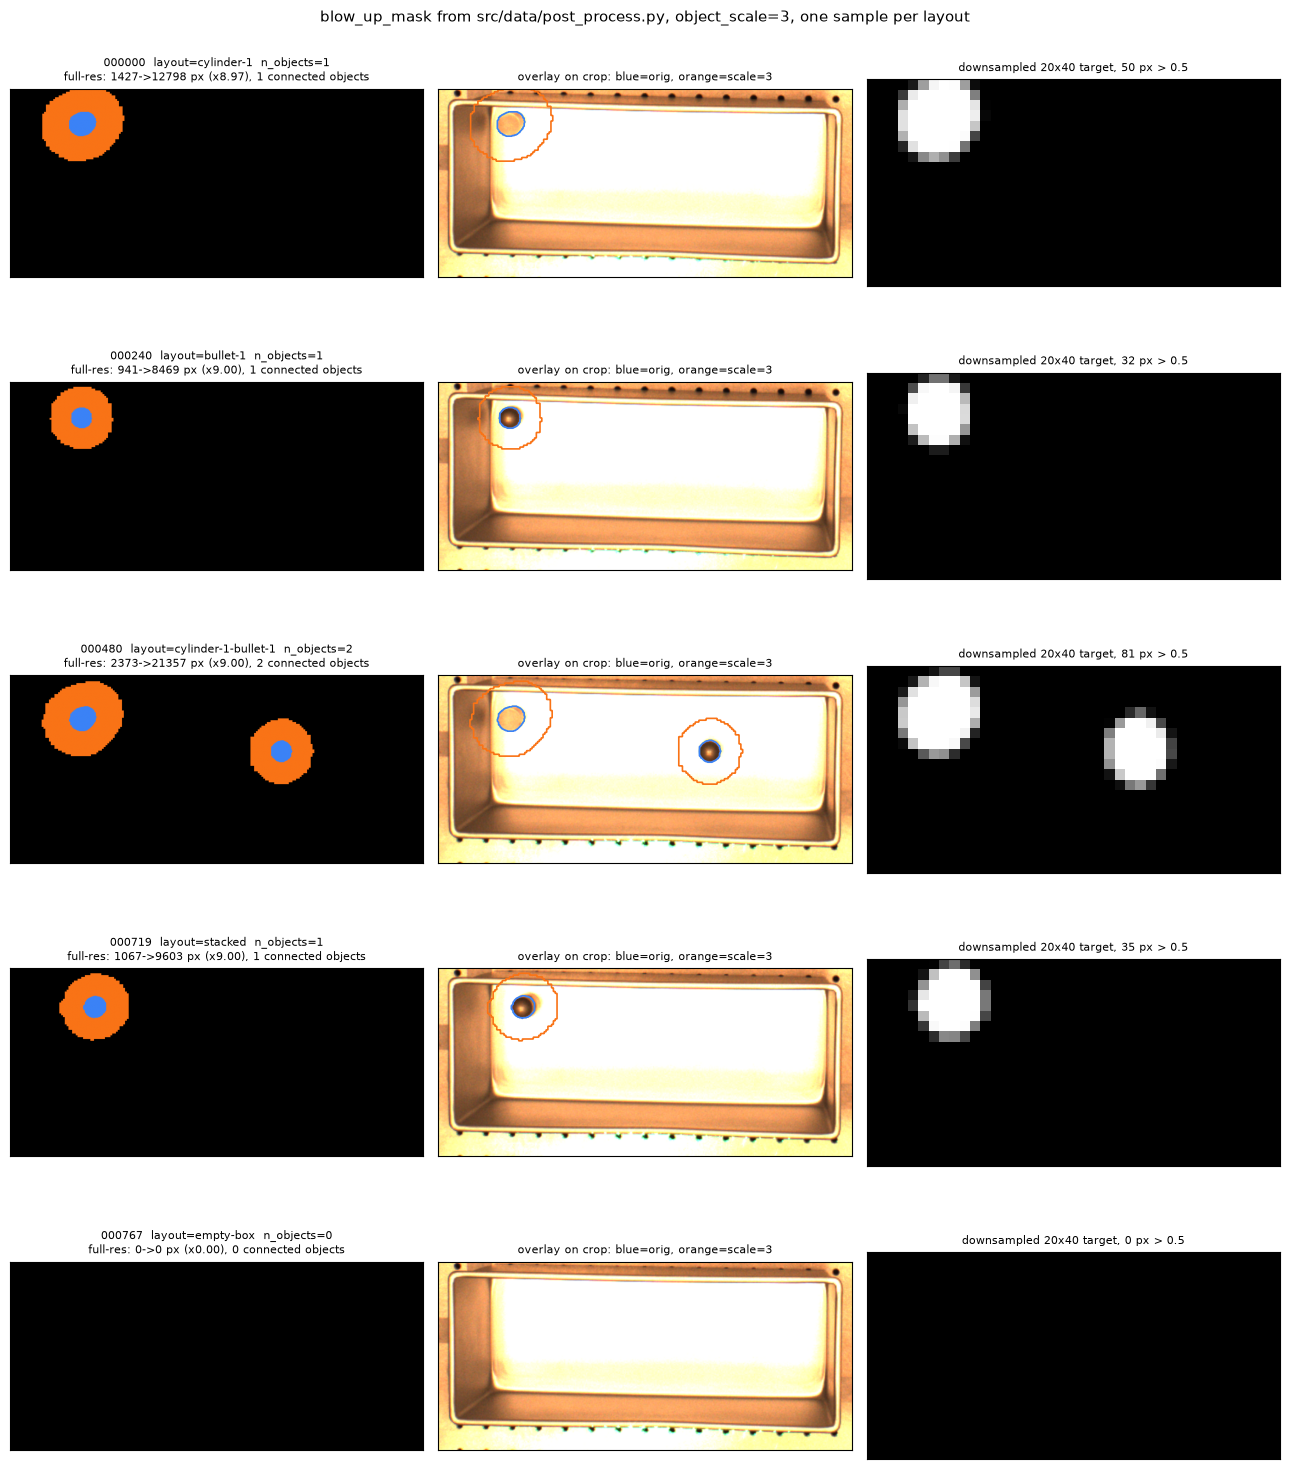

In [9]:
fig, axs = plt.subplots(len(picks), 3, figsize=(13, 3.1*len(picks)))
if len(picks) == 1: axs = axs[None, :]

for i, sid in enumerate(picks):
    d = SAMPLES_DIR / sid
    m = load_meta(d)
    smask_png = Image.open(d / "image/02_smask.png")
    cropped_i = np.asarray(Image.open(d / "image/01_cropped.png"))
    orig = np.array(smask_png) > 127

    blown_png = blow_up_mask(smask_png, OBJECT_SCALE)   # the real shipped function
    blown = np.array(blown_png) > 127
    ds = np.asarray(real_downsample(blown_png, OUT_H, OUT_W), dtype=np.float32) / 255.0

    n_obj_full = ndimage.label(orig)[1]
    ratio = blown.sum() / max(orig.sum(), 1)
    label = f"{sid}  layout={m.get('layout')}  n_objects={m.get('n_objects')}"

    canvas = np.zeros(orig.shape, dtype=int)
    canvas[blown & ~orig] = 1
    canvas[orig] = 2
    axs[i, 0].imshow(ListedColormap(['#000000', ORANGE, BLUE])(canvas / 2))
    axs[i, 0].set_title(f"{label}\nfull-res: {orig.sum()}->{blown.sum()} px (x{ratio:.2f}), {n_obj_full} connected objects", fontsize=8)

    axs[i, 1].imshow(cropped_i)
    axs[i, 1].contour(orig, levels=[0.5], colors=[BLUE], linewidths=1.2)
    axs[i, 1].contour(blown, levels=[0.5], colors=[ORANGE], linewidths=1.2)
    axs[i, 1].set_title("overlay on crop: blue=orig, orange=scale=3", fontsize=8)

    axs[i, 2].imshow(ds, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axs[i, 2].set_title(f"downsampled {OUT_H}x{OUT_W} target, {int((ds>0.5).sum())} px > 0.5", fontsize=8)

    for ax in axs[i]: ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"blow_up_mask from src/data/post_process.py, object_scale={OBJECT_SCALE}, one sample per layout", fontsize=11)
plt.tight_layout(); plt.show()

Empty-box samples have no object at all (`is_empty_box=True`, all-zero mask): `blow_up_mask`
must be a safe no-op there rather than erroring on `ndimage.label` of an all-zero array --
confirmed above (empty-box row, if present, shows an all-black panel with `0->0 px`).

The two-object row (`cylinder-1-bullet-1`) confirms each object grows about its own center of
mass independently, same as the synthetic test in section 5, now on a real capture.

## 8 — Full end-to-end run: the real CLI on the full samples directory

The actual acceptance test: run the shipped CLI exactly as it will be used, over *all* 791
samples in the experiment-24 samples directory, at `--object-scale 3`:

```
python src/data/post_process.py D:\eturok\experiment-24\samples --object-scale 3 --dataset-name cylinder-3x
```

(run with `--no-scp` here to skip the remote push -- this cell only checks that post-processing +
MDS writing succeed locally). Output below is captured from the actual run.

In [10]:
import subprocess

# run from REPO_ROOT (not src/data): that's how it's normally invoked, and the repo relies on
# an implicit CWD-on-sys.path entry (via PYTHONPATH) from the repo root for `utils.*` to resolve
cmd = [sys.executable, "src/data/post_process.py", str(SAMPLES_DIR), "--object-scale", "3",
       "--dataset-name", "cylinder-3x", "--no-scp", "--verbose", "1"]
proc = subprocess.run(cmd, cwd=str(REPO_ROOT), capture_output=True, text=True)
print(proc.stdout[-4000:])
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr[-4000:])
print("return code:", proc.returncode)

Found 791 complete samples (0 skipped)
Hashing metadata of 791 samples to compute cache key ...
Hashing:  48.45 ms
Cache hit: reusing existing MDS at D:\eturok\datasets\014-cylinder-3x\mds
MDS: D:\eturok\datasets\014-cylinder-3x\mds (791 samples)
MDS written to D:\eturok\datasets\014-cylinder-3x\mds (791 samples)
mds:     791 samples, 1.67 GB, D:\eturok\datasets\014-cylinder-3x\mds
samples: 791 samples, 5.14 GB (no symlinks) / 29.74 GB (with symlinks), D:\eturok\datasets\014-cylinder-3x\samples

return code: 0


If the run above succeeded, the new dataset (`cylinder-3x`) sits in `D:\eturok\datasets`
next to the existing versioned dirs, with a `hash.txt` that folds in `object_scale=3` -- rerunning
the same command will cache-hit instead of reprocessing, and any other `--object-scale` value
will allocate a fresh versioned dir.